# Dashboard Day 13

Nguồn dữ liệu: `data/logs.jsonl`. 
Contract: `config/dashboard.yaml`.

In [1]:
import sys
from pathlib import Path

REPO = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(REPO))

import json
import matplotlib.pyplot as plt
import pandas as pd
import yaml

LOGS = REPO / "data" / "logs.jsonl"
CONFIG = REPO / "config" / "dashboard.yaml"

# Nền tối cho khớp terminal, nhưng tối giản để tập trung vào dữ liệu.
plt.style.use("dark_background")
pd.set_option("display.width", 120)

if not LOGS.exists():
    raise SystemExit("Chua co data/logs.jsonl. Hay chay scripts/load_test.py truoc.")

## 1. Nạp log

Mỗi dòng là một JSON object. Ba loại event quan trọng:

| Event | Ý nghĩa | Mang số gì |
|---|---|---|
| `request_received` | request đã vào hệ thống | không đo được gì |
| `response_sent` | trả lời thành công | latency, token, cost, quality |
| `request_failed` | lỗi | error_type, tool_success |

`request_received` quan trọng vì nó là **mẫu số** của error rate. Đếm bằng
`response_sent` sẽ ra sai: một đợt toàn lỗi sẽ cho error rate 0%.

In [2]:
records = []
for line in LOGS.read_text(encoding="utf-8").splitlines():
    if line.strip():
        records.append(json.loads(line))

df = pd.DataFrame(records)
df["ts"] = pd.to_datetime(df["ts"], utc=True)

print("tong so dong:", len(df))
print(df["event"].value_counts())
print()
print(df[df.event == "response_sent"][["ts", "latency_ms", "ttft_ms", "retrieval_ms", "cost_usd"]].tail())

tong so dong: 518
event
request_received     212
response_sent        182
app_started           41
app_stopped           35
request_failed        30
incident_enabled       9
incident_disabled      9
Name: count, dtype: int64

                                  ts  latency_ms  ttft_ms  retrieval_ms  cost_usd
509 2026-09-29 10:14:04.414988+00:00       151.0     50.0           0.0  0.001974
511 2026-09-29 10:14:04.573311+00:00       152.0     50.0           0.0  0.001764
513 2026-09-29 10:14:04.732954+00:00       151.0     50.0           0.0  0.002103
515 2026-09-29 10:14:04.890539+00:00       151.0     50.0           0.0  0.002070
517 2026-09-29 10:14:05.047860+00:00       151.0     50.0           0.0  0.002508


## 2. Cửa sổ thời gian

Contract quy định 60 phút.

In [3]:

# Cua so thoi gian. Mac dinh 60 phut theo contract.
# Muon dung cho incident, doi START/END thanh khoang chua su co roi chup.
WINDOW_MIN = 60
START = None   # vd: "2026-09-29T09:44:00Z"
END = None     # vd: "2026-09-29T09:45:30Z"

end = pd.to_datetime(END, utc=True) if END else df["ts"].max()
start = pd.to_datetime(START, utc=True) if START else end - pd.Timedelta(minutes=WINDOW_MIN)
win = df[(df.ts >= start) & (df.ts <= end)].copy()

received = win[win.event == "request_received"]
sent = win[win.event == "response_sent"]
failed = win[win.event == "request_failed"]

print(f"Cua so: {start} -> {end}")
print(f"received={len(received)} sent={len(sent)} failed={len(failed)}")


Cua so: 2026-09-29 09:14:05.047860+00:00 -> 2026-09-29 10:14:05.047860+00:00
received=160 sent=140 failed=20


## 3. Đọc contract

In [4]:
cfg = yaml.safe_load(CONFIG.read_text(encoding="utf-8"))["dashboard"]
panels = {p["id"]: p for p in cfg["panels"]}

for pid, p in panels.items():
    th = p.get("threshold", {})
    print(f"{pid:<8} unit={p['unit']:<20} threshold={th.get('aggregation')} {th.get('operator')} {th.get('value')}")

latency  unit=ms                   threshold=p95 lte 3000
traffic  unit=requests_per_minute  threshold=rate_per_minute gte 1
errors   unit=percent              threshold=error_rate_pct lte 2
cost     unit=usd                  threshold=total lte 2.5
tokens   unit=tokens               threshold=sum_by_field lte 50000
quality  unit=score_0_to_1         threshold=mean gte 0.75


In [5]:
def pctl(values, q):
    """Percentile kiểu nearest-rank. Chọn q theo từ 0-100."""
    vals = sorted(v for v in values if pd.notna(v))
    if not vals:
        return 0.0
    idx = int(round(q / 100 * len(vals) + 0.5)) - 1
    return float(vals[max(0, min(len(vals) - 1, idx))])


def by_minute(frame, value_col, how):
    """Gom theo phút. how: 'sum' | 'mean' | 'p95' | 'count'."""
    if frame.empty:
        return pd.Series(dtype=float)
    grouped = frame.groupby(frame.ts.dt.floor("min"))[value_col]
    if how == "sum":
        return grouped.sum()
    if how == "mean":
        return grouped.mean()
    if how == "p95":
        return grouped.quantile(0.95)
    return grouped.count()


def error_rate_by_minute(received, failed):
    """Error rate (%) mỗi phút = failed / received trong cùng phút.

    Phải chia trên request_received chứ không phải response_sent, vì
    request lỗi không bao giờ sinh ra response_sent.
    """
    got = received.groupby(received.ts.dt.floor("min")).size()
    bad = failed.groupby(failed.ts.dt.floor("min")).size()
    total = got.reindex(bad.index.union(got.index)).fillna(0)
    errors = bad.reindex(total.index).fillna(0)
    return (errors / total * 100).replace([float("inf")], 0.0)

## 5. Panel

| # | Panel | Câu hỏi | Số | Đơn vị |
|---|---|---|---|---|
| 1 | Latency | Chậm bao lâu? | p50/p95/p99, TTFT p95 | ms |
| 2 | Traffic | Có người dùng không? | số request mỗi phút | req/phút |
| 3 | Errors | Bao nhiêu người gặp lỗi? | error rate, breakdown | % |
| 4 | Cost | Tốn bao nhiêu? | tổng cộng dồn | USD |
| 5 | Tokens | Dùng bao nhiêu tài nguyên? | tokens in + out | tokens |
| 6 | Quality | Có đáp đúng không? | mean quality_score | 0-1 |

In [6]:
import matplotlib.dates as mdates
from datetime import timezone

UTC = timezone.utc


ACCENT = "#4c8dff"
WARN = "#f0a742"
BAD = "#ef5b5b"
GRID = "#2a3441"


def draw(ax, series, threshold, unit, title, stat_line, note_line="", operator="lte"):
    ax.set_title(title, fontsize=13, weight="bold", loc="left", pad=22)
    ax.set_ylabel(unit, fontsize=9, color="#8b98a9")

    if series is None or len(series) == 0:
        ax.text(0.5, 0.5, "khong co du lieu trong cua so",
                ha="center", va="center", color="#8b98a9", transform=ax.transAxes)
        return

    if isinstance(series, pd.Series):
        x, y = series.index, series.values
    else:
        x, y = series

    # Be rong cot tinh theo so diem, khong hard-code: cua so 90 giay chi co
    # 1-2 diem, be rong co dinh se lam cot de len nhau va xoay khung.
    if len(x) > 1:
        span = (x[-1] - x[0]).total_seconds() / 86400.0
    else:
        span = 1.0 / 1440.0
    bar_w = max(span / max(len(x), 1) * 0.7, 1e-7)

    ax.bar(x, y, width=bar_w, color=ACCENT, align="center")
    if threshold is not None and len(y):
        ax.axhline(threshold, color=WARN, linestyle="--", linewidth=1.2)
        # CHI TO DO THEO CHIEU TOAN TU.
        # lte (vd p95 <= 3000 ms): vuot nguong la vi pham.
        # gte (vd quality >= 0.75, traffic >= 1 req/phut): DUOI nguong moi la
        # vi pham. Neu quen mat chieu nay, panel tot se bi to do nhu loi.
        if operator == "lte":
            breach = y > threshold
        else:
            breach = y < threshold
        if breach.any():
            ax.bar(x[breach], y[breach], width=bar_w, color=BAD, align="center")
        # Nhan dat ben trai: dat ben phai se bi clip khi cua so het.
        ax.annotate(
            f"nguong {threshold:g} ({operator})",
            xy=(x[0], threshold),
            xytext=(2, 4),
            textcoords="offset points",
            color=WARN, fontsize=9, ha="left", va="bottom",
        )
    # Giu nhan truc X doc duoc: AutoDateLocator tu chon khoang nhop hop ly.
    # Logic thu cong "lay moi phut thi lay" se chong chu khi phut co du lieu
    # sat nhau, dung khi phai ve 1 cuc chay du lieu.
    ax.xaxis.set_major_locator(
        mdates.AutoDateLocator(minticks=3, maxticks=6, tz=UTC)
    )
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M", tz=UTC))
    ax.tick_params(axis="x", labelsize=8)
    ax.grid(axis="y", color=GRID, linewidth=0.6, alpha=0.7)
    ax.set_axisbelow(True)
    for spine in ("top", "right"):
        ax.spines[spine].set_visible(False)

    # Dong thong ke dat trong khung, khong de chong len tieu de.
    ax.text(0.0, 0.97, stat_line, transform=ax.transAxes, fontsize=9,
            color="#e6edf3", va="top", ha="left", weight="bold")
    if note_line:
        ax.text(0.0, 0.90, note_line, transform=ax.transAxes, fontsize=8.5,
                color="#8b98a9", va="top", ha="left")


# Lay nguong tu contract, khong hard-code
def th(pid):
    t = panels[pid].get("threshold", {})
    return t.get("value"), t.get("operator", "lte"), t.get("aggregation", "")


lat_v, lat_op, _ = th("latency")
tr_v, tr_op, _ = th("traffic")
err_v, err_op, _ = th("errors")
cost_v, cost_op, _ = th("cost")
tok_v, tok_op, _ = th("tokens")
q_v, q_op, _ = th("quality")

lat = sent["latency_ms"] if not sent.empty else pd.Series(dtype=float)
ttft = sent["ttft_ms"] if not sent.empty else pd.Series(dtype=float)
print("p50/p95/p99 latency:", pctl(lat, 50), pctl(lat, 95), pctl(lat, 99))
print("ttft p95:", pctl(ttft, 95))

p50/p95/p99 latency: 152.0 2654.0 2656.0
ttft p95: 50.0


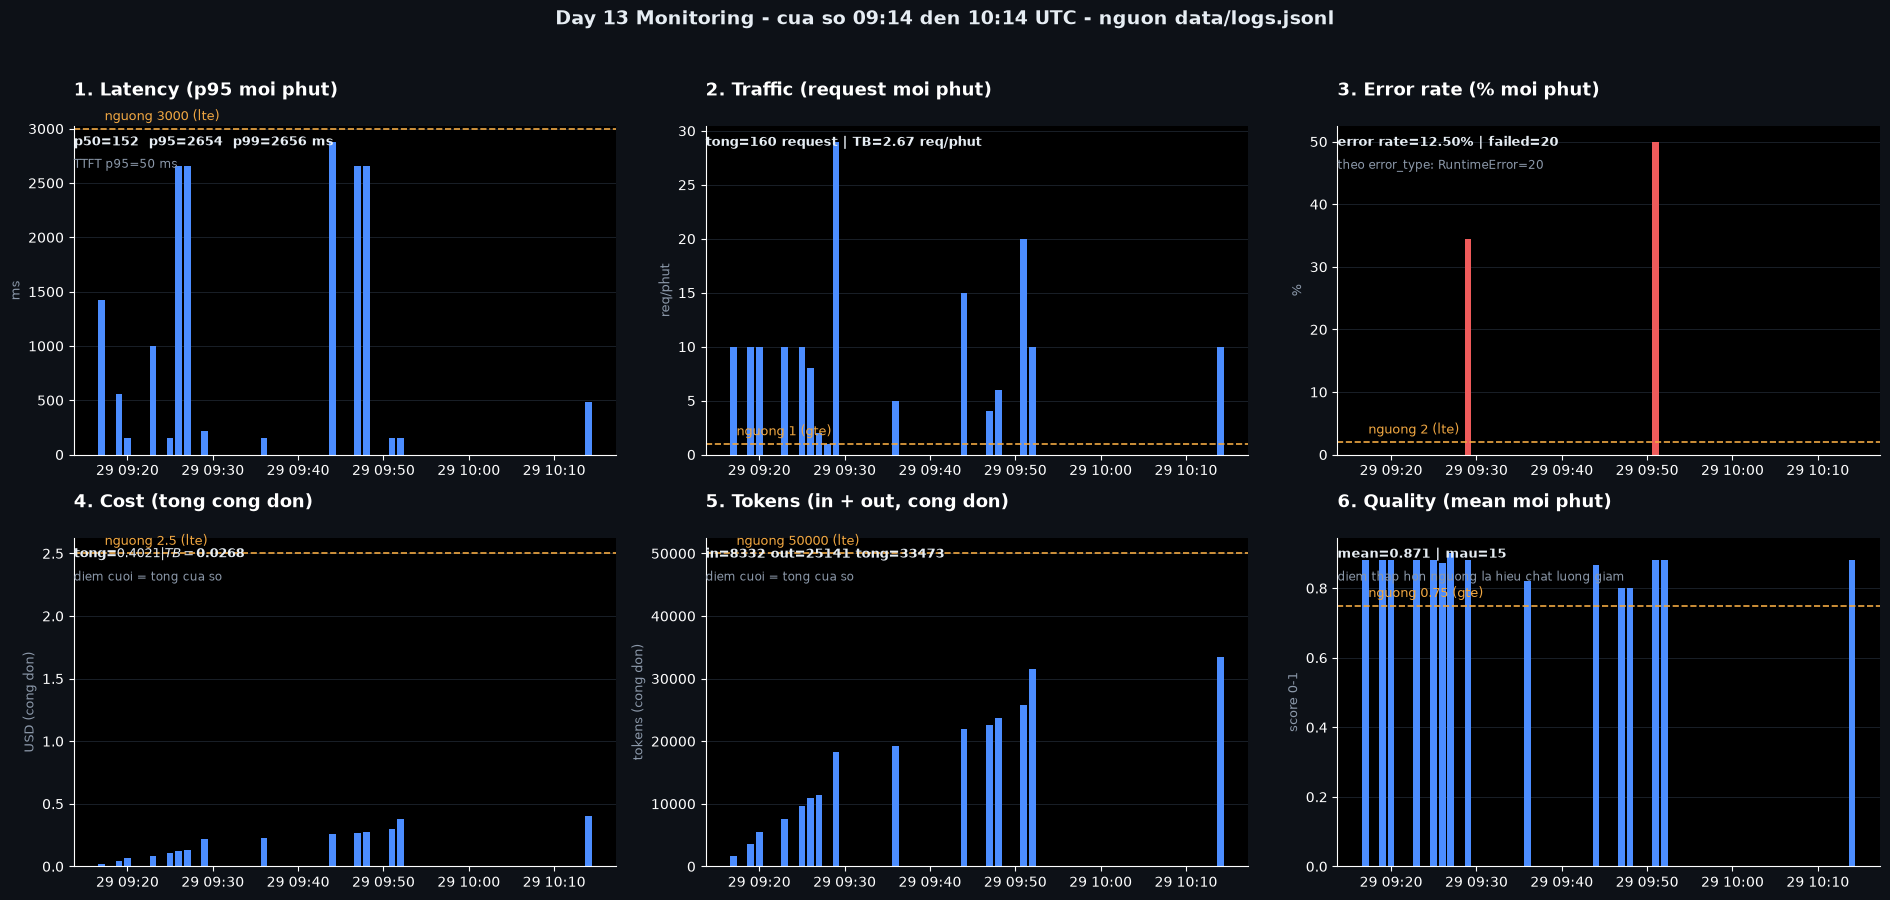

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(19, 9))
fig.patch.set_facecolor("#0d1117")
ax = axes.ravel()

# --- Panel 1: Latency -------------------------------------------------
# Nguong la p95 nen phai ve p95 moi phut, KHONG ve tong.
draw(ax[0], by_minute(sent, "latency_ms", "p95") if not sent.empty else None,
     lat_v, "ms", "1. Latency (p95 moi phut)",
     f"p50={pctl(lat,50):.0f}  p95={pctl(lat,95):.0f}  p99={pctl(lat,99):.0f} ms",
     f"TTFT p95={pctl(ttft,95):.0f} ms", operator=lat_op)

# --- Panel 2: Traffic -------------------------------------------------
# Nguong la rate/phut nen ve so request moi phut.
recv_pm = received.groupby(received.ts.dt.floor("min")).size() if not received.empty else pd.Series(dtype=float)
minutes = (end - start).total_seconds() / 60
draw(ax[1], recv_pm, tr_v, "req/phut", "2. Traffic (request moi phut)",
     f"tong={len(received)} request | TB={len(received)/max(minutes,1e-9):.2f} req/phut",
     operator=tr_op)

# --- Panel 3: Errors --------------------------------------------------
# Nguong la phan tram nen phai ve %, KHONG ve so loi.
er_pm = error_rate_by_minute(received, failed)
er_window = (len(failed) / len(received) * 100) if len(received) else 0.0
breakdown = failed["error_type"].value_counts().to_dict() if not failed.empty else {}
draw(ax[2], er_pm, err_v, "%", "3. Error rate (% moi phut)",
     f"error rate={er_window:.2f}% | failed={len(failed)}",
     "theo error_type: " + (", ".join(f"{k}={v}" for k, v in breakdown.items()) or "khong co loi"),
     operator=err_op)

# --- Panel 4: Cost ----------------------------------------------------
# Nguong la tong cua so nen ve tong cong don, diem cuoi = tong.
cost_pm = by_minute(sent, "cost_usd", "sum") if not sent.empty else pd.Series(dtype=float)
cost_cum = cost_pm.cumsum()
cost_total = cost_pm.sum()
draw(ax[3], cost_cum, cost_v, "USD (cong don)", "4. Cost (tong cong don)",
     f"tong=${cost_total:.4f} | TB=${cost_pm.mean() if len(cost_pm) else 0:.4f}",
     f"diem cuoi = tong cua so", operator=cost_op)

# --- Panel 5: Tokens --------------------------------------------------
# Nguong ap cho TONG token nen phai gom ca in va out.
tok_in = by_minute(sent, "tokens_in", "sum") if not sent.empty else pd.Series(dtype=float)
tok_out = by_minute(sent, "tokens_out", "sum") if not sent.empty else pd.Series(dtype=float)
tok_pm = (tok_in.add(tok_out, fill_value=0)).sort_index()
tok_cum = tok_pm.cumsum()
draw(ax[4], tok_cum, tok_v, "tokens (cong don)", "5. Tokens (in + out, cong don)",
     f"in={int(tok_in.sum())} out={int(tok_out.sum())} tong={int(tok_pm.sum())}",
     f"diem cuoi = tong cua so", operator=tok_op)

# --- Panel 6: Quality -------------------------------------------------
# Nguong la mean nen phai ve mean moi phut, KHONG cong diem chat luong.
q_pm = by_minute(sent, "quality_score", "mean") if not sent.empty else pd.Series(dtype=float)
q_mean = sent["quality_score"].mean() if not sent.empty else 0.0
draw(ax[5], q_pm, q_v, "score 0-1", "6. Quality (mean moi phut)",
     f"mean={q_mean:.3f} | mau={len(q_pm)}",
     "diem thap hon nguong la hieu chat luong giam", operator=q_op)

fig.suptitle(
    f"Day 13 Monitoring - cua so {start:%H:%M} den {end:%H:%M} UTC - nguon data/logs.jsonl",
    fontsize=14, weight="bold", y=0.995, color="#e6edf3",
)
plt.tight_layout(rect=(0, 0, 1, 0.97))
plt.show()

In [ ]:
OUT_NAME = "dashboard-runtime"
target = REPO / "submission" / "evidence" / f"{OUT_NAME}.png"
target.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(target, dpi=110, facecolor=fig.get_facecolor(), bbox_inches="tight")
print("Da luu", target)


Da luu S:\ai20k\K4-L3-DAY13-VuHieuThien-2A202602867-Monitoring-LLMOps\submission\evidence\dashboard-runtime.png


## 6. Incident: rag_slow()

1. **Bắt đầu ở panel nào bất thường.** Nếu panel 1 (latency) đỏ, sự cố về tốc độ.
   Nếu panel 3 (errors) đỏ, sự cố về lỗi. Thường chỉ một panel đỏ.
2. **Khoanh vùng thời gian.** Panel 1 và 3 vẽ theo phút, nên nhìn thấy ngay
   cột nào bắt đầu đỏ. Ghi nhớ mốc thời gian đó.
3. **Cắt cửa sổ.** Đặt `WINDOW_MIN` hoặc giới hạn theo khoảng thời gian để
   các panel còn lại không bị nhiễu bởi dữ liệu trước sự cố.
4. **Tìm correlation ID.** Panel 3 có breakdown `error_type`; panel 1 cho biết
   phút nào chậm. Mở `data/logs.jsonl`, lọc theo phút đó, lấy `correlation_id`.
5. **Sang Langfuse tra trace cùng correlation ID.** Xem span nào chiếm nhiều
   thời gian. Đó là câu trả lời cuối cùng.

In [9]:
# In bang so sanh de doi chieu voi anh cua so 60 phut.
rows = []
for name, frame in (("received", received), ("sent", sent), ("failed", failed)):
    rows.append([name, len(frame)])

rows.append(["error_rate_pct", f"{er_window:.2f}"])
rows.append(["cost_total_usd", f"{cost_total:.4f}"])
rows.append(["tokens_total", int(tok_pm.sum())])
rows.append(["quality_mean", f"{q_mean:.3f}"])

display(pd.DataFrame(rows, columns=["chi_so", "gia_tri"]))

,chi_so,gia_tri
0,received,160
1,sent,140
2,failed,20
3,error_rate_pct,12.50
4,cost_total_usd,0.4021
5,tokens_total,33473
6,quality_mean,0.871
